Before starting, follow this four steps to run the notebook on Google Colab

https://river-runner-global.samlearner.com/

Step 1. Clone GitHub repository with notebooks and data for the course

In [2]:
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

fatal: destination path 'Hidrology_Course' already exists and is not an empty directory.


In [3]:
ls

Hidrology_Course/  sample_data/


Step 2: Let's move to the cloned folder


In [2]:
%cd Hidrology_Course

/content/Hidrology_Course


In [ ]:
ls

01_Delimitacion_cuenca.ipynb  Data/  README.md


# Delimitación de cuenca hidrográfica

Este notebook permite delimitar una cuenca hidrográfica a partir de:

- un DEM (`dem.tif`)
- un punto de salida definido con coordenadas `lon/lat`

Está pensado para ejecutarse en **Google Colab** con librerías comunes y código simple, claro y bien comentado.


In [3]:
# Instalar librerías necesarias
!pip -q install leafmap pysheds rasterio geopandas shapely

In [20]:
# Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
import geopandas as gpd

from pysheds.grid import Grid
import leafmap.foliumap as leafmap
from rasterio.plot import show

import os
import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.enums import Resampling
from rasterio.features import shapes
from rasterio.warp import transform

import geopandas as gpd
from shapely.geometry import shape

from pysheds.grid import Grid

## 1. Mostrar mapa base

Usa este mapa solo para ubicar visualmente la zona de estudio y elegir el punto de salida.
En esta primera versión, las coordenadas del punto se ingresan manualmente.


In [8]:
# Crear mapa base
m = leafmap.Map()
m.add_basemap("OpenTopoMap")
m

In [5]:
# Crear mapa base en un punto específico
m = leafmap.Map(center=[-36.59433389487894, -72.08269046506874], zoom=15)
m.add_basemap("OpenTopoMap")
m

## 2. Definir la ruta del DEM

Antes de ejecutar esta parte, sube a Colab un archivo llamado `dem.tif`.


DEM oficial Hidrografía Chile (DGA)
https://lineasdebasepublicas.mma.gob.cl/datos_abiertos/dataset/hidrosfera/resource/0c159d9e-4378-40f0-80da-240aad755a21?utm_source=chatgpt.com

In [6]:
ls

01_Delimitacion_cuenca.ipynb  Data/  README.md


2) ruta del DEM original

In [7]:
# Ruta del DEM
dem_path = "Data/Ñuble/REGION_NUBLE_1.jp2"

if not os.path.exists(dem_path):
    raise FileNotFoundError(
        "No se encontró el archivo DEM"
    )

print("DEM encontrado:", dem_path)



DEM encontrado: Data/Ñuble/REGION_NUBLE_1.jp2


revisar resolución

In [10]:
with rasterio.open(dem_path) as src:
    print("Resolución original (x, y):", src.res)
    print("Ancho (pixeles):", src.width)
    print("Alto (pixeles):", src.height)
    print("CRS:", src.crs)

Resolución original (x, y): (0.00011559404618781494, 0.00011559404618781474)
Ancho (pixeles): 18547
Alto (pixeles): 12783
CRS: GEOGCS["GCS_SIRGAS_Chile",DATUM["SIRGAS-Chile",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1064"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


≈ 237 millones de píxeles

3) crear DEM de baja resolución

In [15]:
dem_lowres_path = "Data/Ñuble/REGION_NUBLE_1_lowres.tif"

scale_factor = 8   # prueba también 5 o 10

with rasterio.open(dem_path) as src:
    data = src.read(
        1,
        out_shape=(
            int(src.height / scale_factor),
            int(src.width / scale_factor)
        ),
        resampling=Resampling.average
    )

    transform_lowres = src.transform * src.transform.scale(
        (src.width / data.shape[1]),
        (src.height / data.shape[0])
    )

    profile = src.profile.copy()
    profile.update({
        "driver": "GTiff",
        "height": data.shape[0],
        "width": data.shape[1],
        "transform": transform_lowres,
        "dtype": data.dtype
    })

    with rasterio.open(dem_lowres_path, "w", **profile) as dst:
        dst.write(data, 1)

print("DEM lowres guardado en:", dem_lowres_path)

DEM lowres guardado en: Data/Ñuble/REGION_NUBLE_1_lowres.tif


4) revisar resolución original y nueva

In [16]:
with rasterio.open(dem_path) as src:
    print("Resolución original:", src.res)
    print("Dimensiones originales:", src.width, "x", src.height)

with rasterio.open(dem_lowres_path) as src:
    print("Resolución lowres:", src.res)
    print("Dimensiones lowres:", src.width, "x", src.height)

Resolución original: (0.00011559404618781494, 0.00011559404618781474)
Dimensiones originales: 18547 x 12783
Resolución lowres: (0.0009249019735312354, 0.0009252590434682753)
Dimensiones lowres: 2318 x 1597


5) mostrar DEM lowres

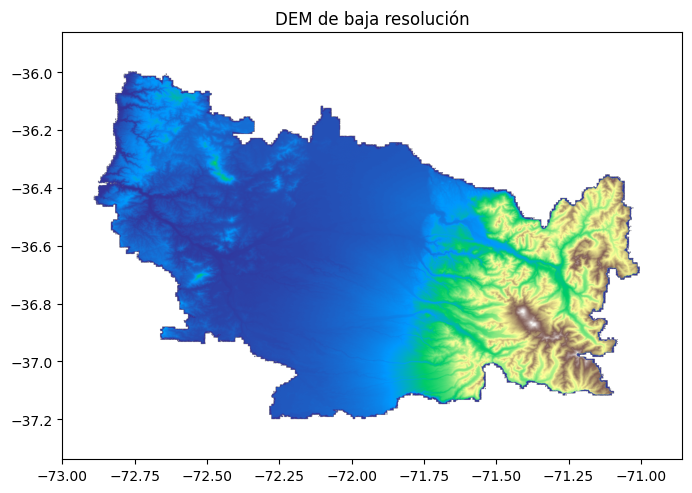

In [17]:
from rasterio.plot import show

with rasterio.open(dem_lowres_path) as src:
    dem_plot = src.read(1).astype(float)

    if src.nodata is not None:
        dem_plot[dem_plot == src.nodata] = np.nan

    fig, ax = plt.subplots(figsize=(8, 8))
    show(dem_plot, transform=src.transform, cmap="terrain", ax=ax)
    ax.set_title("DEM de baja resolución")
    plt.show()

6) preparar DEM para análisis hidrológico

In [18]:
grid = Grid.from_raster(dem_lowres_path)
dem = grid.read_raster(dem_lowres_path)

print("Rellenando depresiones...")
dem_filled = grid.fill_depressions(dem)

print("Resolviendo zonas planas...")
dem_inflated = grid.resolve_flats(dem_filled)

print("Calculando dirección de flujo...")
fdir = grid.flowdir(dem_inflated)

print("Calculando acumulación...")
acc = grid.accumulation(fdir)

print("DEM listo para el análisis hidrológico.")

Rellenando depresiones...
Resolviendo zonas planas...
Calculando dirección de flujo...
Calculando acumulación...
DEM listo para el análisis hidrológico.


## 7. Definir el punto de salida

Reemplaza estos valores por las coordenadas del punto ubicado sobre el río.


In [14]:
# Coordenadas del punto de salida
outlet_lon = -72.95
outlet_lat = -36.82

print(f"Punto de salida: lon={outlet_lon}, lat={outlet_lat}")

Punto de salida: lon=-72.95, lat=-36.82


8) convertir el punto al CRS del DEM lowres

Aquí se corrigen depresiones y zonas planas para que el flujo superficial pueda calcularse correctamente.


In [21]:
with rasterio.open(dem_lowres_path) as src:
    print("CRS DEM:", src.crs)

    x_out, y_out = transform("EPSG:4326", src.crs, [outlet_lon], [outlet_lat])
    x_out = x_out[0]
    y_out = y_out[0]

print("Punto transformado al CRS del DEM:")
print("x =", x_out)
print("y =", y_out)

CRS DEM: EPSG:5360
Punto transformado al CRS del DEM:
x = -72.95
y = -36.82


9) convertir el punto a fila y columna

In [22]:
with rasterio.open(dem_lowres_path) as src:
    row, col = src.index(x_out, y_out)

print("Fila:", row)
print("Columna:", col)

Fila: 1036
Columna: 54


10) delimitar la cuenca


In [23]:
catch = grid.catchment(
    x=col,
    y=row,
    fdir=fdir,
    xytype="index"
)

print("Cuenca delimitada correctamente.")

Cuenca delimitada correctamente.


11) visualizar la cuenca


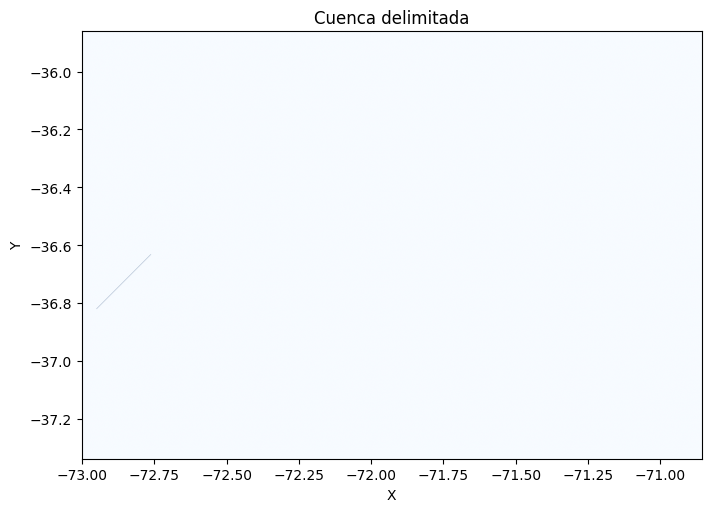

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(catch, extent=grid.extent, cmap="Blues")
ax.set_title("Cuenca delimitada")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

12) mostrar acumulación + punto de salida

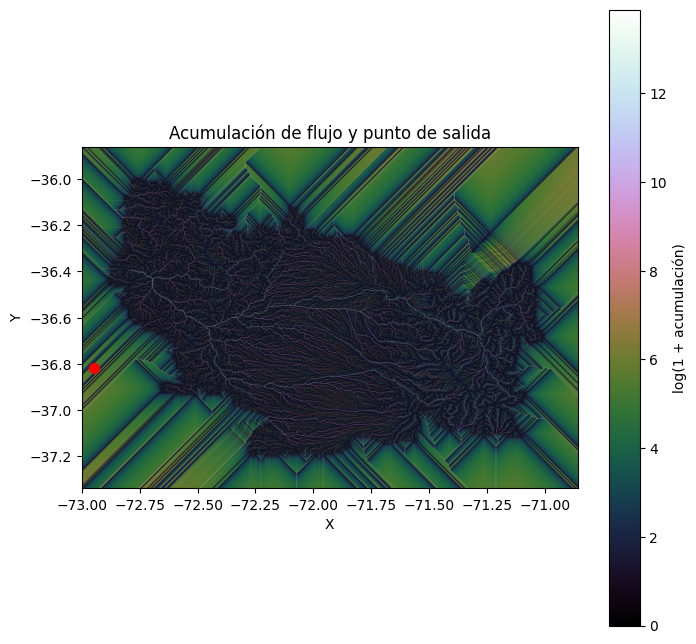

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(
    np.log1p(acc),
    extent=grid.extent,
    cmap="cubehelix"
)

ax.scatter(x_out, y_out, s=50, c="red")
ax.set_title("Acumulación de flujo y punto de salida")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.colorbar(im, ax=ax, label="log(1 + acumulación)")
plt.show()

## 9. Convertir la cuenca a polígono

Esto permite exportar el resultado a formatos GIS como GeoJSON o Shapefile.


In [26]:
mask = catch.astype(np.uint8)

results = shapes(mask, mask=mask > 0, transform=grid.affine)
geoms = [shape(geom) for geom, value in results if value == 1]

if len(geoms) == 0:
    raise ValueError("No se pudo generar el polígono de la cuenca.")

gdf = gpd.GeoDataFrame(geometry=geoms, crs=grid.crs)
gdf = gdf.dissolve().explode(index_parts=False).reset_index(drop=True)

gdf.head()

,geometry
0,"POLYGON ((-72.95085 -36.81948, -72.94992 -36.8..."
1,"POLYGON ((-72.949 -36.81856, -72.949 -36.81948..."
2,"POLYGON ((-72.949 -36.81856, -72.949 -36.81763..."
3,"POLYGON ((-72.94807 -36.81671, -72.94715 -36.8..."
4,"POLYGON ((-72.94622 -36.81578, -72.94622 -36.8..."


## 10. Guardar resultados


In [27]:
output_geojson = "Data/Ñuble/cuenca_demo.geojson"
output_shp = "Data/Ñuble/cuenca_demo.shp"

gdf_wgs84 = gdf.to_crs("EPSG:4326")

gdf_wgs84.to_file(output_geojson, driver="GeoJSON")
gdf_wgs84.to_file(output_shp)

print("Archivos exportados:")
print(output_geojson)
print(output_shp)

Archivos exportados:
Data/Ñuble/cuenca_demo.geojson
Data/Ñuble/cuenca_demo.shp
